# DRL02 Policy Gradient with PyTorch

### Lab Description

This laboratory develops policy-based reinforcement learning from first principles. MiniGrid first uses a **tabular softmax policy**, keeping every action probability and REINFORCE update explicit. CartPole and PixelCopter then use PyTorch policy networks for continuous feature vectors while preserving the same Monte Carlo policy-gradient estimator.

MiniGrid learning runs entirely on the CPU with NumPy. For CartPole and PixelCopter, environment interaction remains sequential CPU work, while trajectory tensors, policy forward passes, losses, and gradients run on an AMD Radeon GPU through ROCm. The neural sections intentionally stop if an AMD ROCm device is unavailable rather than silently falling back to slow CPU training.

Visualizations include action distributions, tabular probability maps, learning curves, a CPU/GPU batch-update benchmark, accelerator statistics, and animated rollouts for all three environments.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (for example, Ryzen™ AI Max+ PRO 395 or Ryzen™ AI Max 390). The CartPole and PixelCopter sections require the integrated Radeon GPU through ROCm.

#### Software Environment

OS: Ubuntu 24.04 LTS  
Python 3.12 with Gymnasium, MiniGrid, ROCm-enabled PyTorch, and the PyGame Learning Environment in the [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=max-pro-395) environment.

## Goals

- Distinguish value-based and policy-based reinforcement learning
- Convert policy preferences into action probabilities with softmax
- Explain the log-derivative policy-gradient estimator
- Compute discounted return-to-go from a trajectory
- Implement tabular REINFORCE with a state baseline for MiniGrid
- Build PyTorch policy networks for CartPole and PixelCopter
- Reuse one REINFORCE estimator across tabular and continuous-vector states
- Explain why the loss uses negative return-weighted log probability
- Evaluate stochastic and greedy policies separately
- Inspect a tabular probability map and animated rollouts
- Require AMD ROCm placement for every neural-policy training and evaluation path
- Compare CPU and AMD GPU throughput for batched policy updates
- Explain why sequential environment steps do not by themselves saturate a GPU

## 1. Setup

The setup cell installs only missing environment packages. PyTorch comes from the AUP Learning Cloud ROCm image; installing a generic wheel here could replace the AMD-compatible build.

Sections 2–4 use only NumPy tables and can run on the CPU. Section 5 calls `require_amd_gpu()` before creating any policy network. If PyTorch cannot see an AMD ROCm device, the neural portion stops with a clear error instead of training on the CPU.

In [1]:
import importlib.util
import contextlib
import io
import os
import site
import subprocess
import sys
import time


os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

required_packages = {
    "gymnasium": "gymnasium",
    "minigrid": "minigrid",
    "imageio": "imageio",
    "ple": "git+https://github.com/ntasfi/PyGame-Learning-Environment.git",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--user",
            "--quiet",
            "--no-warn-script-location",
            *missing_packages,
        ]
    )
    site.addsitedir(site.getusersitepackages())

if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "PyTorch is missing. Start this notebook with the AUP Learning Cloud "
        "ROCm image instead of installing a generic PyTorch wheel."
    )

from dataclasses import dataclass
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
import minigrid
import numpy as np
import torch
import torch.nn as nn
from IPython.display import Image, display
from torch.distributions import Categorical

with contextlib.redirect_stdout(io.StringIO()):
    from ple import PLE
    from ple.games.pixelcopter import Pixelcopter

torch.set_num_threads(min(4, os.cpu_count() or 1))

print("Python:", sys.version.split()[0])
print("Gymnasium:", gym.__version__)
print("MiniGrid:", minigrid.__version__)
print("PyTorch:", torch.__version__)
print("ROCm/HIP:", torch.version.hip or "not available")
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.12.3
Gymnasium: 1.3.0
MiniGrid: 3.1.0
PyTorch: 2.9.1+rocm7.13.0
ROCm/HIP: 7.13.99004-3309c6114a
NumPy: 2.4.6
Matplotlib: 3.11.0


In [2]:
SEED = 17
ENV_NAME = "MiniGrid-Empty-8x8-v0"
NAV_ACTIONS = np.array([0, 1, 2], dtype=int)
ACTION_NAMES = ("left", "right", "forward")
ACTION_SYMBOLS = ("L", "R", "↑")
DIRECTION_SYMBOLS = ("→", "↓", "←", "↑")
ARTIFACT_DIR = Path("artifacts") / "DRL02"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)

ROCM_AVAILABLE = bool(
    torch.cuda.is_available() and torch.version.hip is not None
)
ROCM_DEVICE = torch.device("cuda:0") if ROCM_AVAILABLE else None
if ROCM_AVAILABLE:
    torch.cuda.manual_seed_all(SEED)

print("MiniGrid tabular device: CPU")
if ROCM_AVAILABLE:
    properties = torch.cuda.get_device_properties(ROCM_DEVICE)
    print("Neural-policy device:", ROCM_DEVICE)
    print("Accelerator backend: ROCm/HIP")
    print("AMD GPU:", torch.cuda.get_device_name(ROCM_DEVICE))
    print(f"Visible GPU memory: {properties.total_memory / 2**30:.1f} GiB")
else:
    print(
        "AMD ROCm GPU not detected. Sections 2–4 can still run; "
        "Section 5 and later will stop before creating a policy network."
    )
print("Artifacts:", ARTIFACT_DIR.resolve())


def seed_torch(seed):
    torch.manual_seed(seed)
    if ROCM_AVAILABLE:
        torch.cuda.manual_seed_all(seed)


def model_device(model):
    return next(model.parameters()).device


def require_amd_gpu(device=None):
    if not ROCM_AVAILABLE:
        raise RuntimeError(
            "CartPole and PixelCopter require the AUP Learning Cloud "
            "ROCm image and a visible AMD GPU. CPU fallback is disabled."
        )
    resolved_device = (
        ROCM_DEVICE if device is None else torch.device(device)
    )
    if resolved_device.type != "cuda":
        raise RuntimeError(
            "Neural-policy training must use the AMD ROCm GPU; "
            f"received device={resolved_device}."
        )
    return resolved_device


def make_env(render_mode=None):
    return gym.make(ENV_NAME, render_mode=render_mode)


def get_agent_state(env):
    x, y = map(int, env.unwrapped.agent_pos)
    return x, y, int(env.unwrapped.agent_dir)


def stable_softmax(logits, temperature=1.0):
    scaled = np.asarray(logits, dtype=float) / temperature
    shifted = scaled - np.max(scaled)
    probabilities = np.exp(shifted)
    return probabilities / probabilities.sum()


def moving_average(values, window=50):
    values = np.asarray(values, dtype=float)
    smooth = np.convolve(values, np.ones(window) / window, mode="valid")
    return np.arange(window - 1, len(values)), smooth

MiniGrid tabular device: CPU
Neural-policy device: cuda:0
Accelerator backend: ROCm/HIP
AMD GPU: Radeon 8060S Graphics
Visible GPU memory: 64.0 GiB
Artifacts: /home/jovyan/work/artifacts/DRL02


## 2. MiniGrid as a Policy-Learning Problem

MiniGrid actions are relative to the agent's orientation. To keep the policy output compact, we use the three navigation actions **left**, **right**, and **forward**. A state is the tuple $(x,y,d)$ containing position and direction.

The full Gymnasium interface remains unchanged:

~~~text
observation, info = env.reset(seed=...)
next_observation, reward, terminated, truncated, info = env.step(action)
~~~

True termination means the agent reached the green goal. Truncation means the time limit ended the episode.

In [3]:
preview_env = make_env()
observation, info = preview_env.reset(seed=SEED)
initial_state = get_agent_state(preview_env)

print("Environment:", ENV_NAME)
print("Observation keys:", tuple(observation.keys()))
print("Full action space:", preview_env.action_space)
print("Policy actions:", dict(enumerate(ACTION_NAMES)))
print("Initial state:", initial_state)
print("Mission:", observation["mission"])
preview_env.close()

Environment: MiniGrid-Empty-8x8-v0
Observation keys: ('image', 'direction', 'mission')
Full action space: Discrete(7)
Policy actions: {0: 'left', 1: 'right', 2: 'forward'}
Initial state: (1, 1, 0)
Mission: get to the green goal square


## 3. From Action Values to a Stochastic Policy

A value-based method represents $Q(s,a)$ and derives a policy by selecting a high-value action. A policy-based method represents the action distribution directly:

$$
\pi_\theta(a\mid s)=P(A_t=a\mid S_t=s;\theta).
$$

For discrete actions, softmax converts unrestricted preferences or logits $h_\theta(s,a)$ into probabilities:

$$
\pi_\theta(a\mid s)
=
\frac{\exp(h_\theta(s,a)/\tau)}
{\sum_b \exp(h_\theta(s,b)/\tau)}.
$$

The temperature $\tau$ controls how concentrated the distribution is. High temperature makes probabilities similar; low temperature approaches greedy selection. Subtracting the largest logit before exponentiation prevents numerical overflow without changing the probabilities.

Unlike ε-greedy exploration, a softmax policy is stochastic by construction. Learning changes the entire distribution rather than switching between a greedy and a random mode.

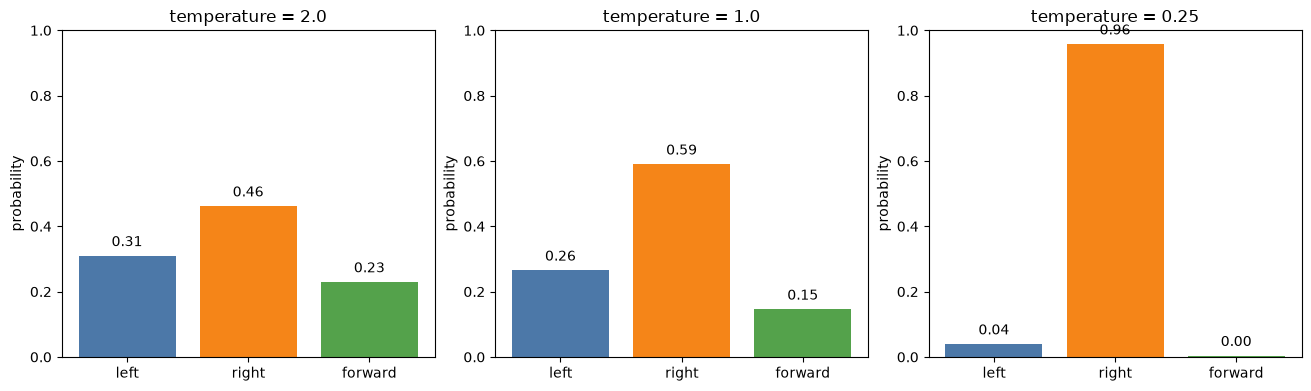

Logits: {'left': np.float64(0.2), 'right': np.float64(1.0), 'forward': np.float64(-0.4)}


In [4]:
example_logits = np.array([0.2, 1.0, -0.4])
temperatures = [2.0, 1.0, 0.25]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
for axis, temperature in zip(axes, temperatures):
    probabilities = stable_softmax(example_logits, temperature)
    axis.bar(ACTION_NAMES, probabilities, color=["#4c78a8", "#f58518", "#54a24b"])
    axis.set_title(f"temperature = {temperature}")
    axis.set_ylim(0, 1)
    axis.set_ylabel("probability")
    for index, probability in enumerate(probabilities):
        axis.text(index, probability + 0.03, f"{probability:.2f}", ha="center")
plt.show()

print("Logits:", dict(zip(ACTION_NAMES, example_logits)))

## 4. Tabular REINFORCE

REINFORCE is a Monte Carlo policy-gradient algorithm. It samples a complete trajectory, computes return-to-go,

$$
G_t = R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots,
$$

and applies the log-derivative estimator

$$
\nabla_\theta J(\theta)
\approx
\sum_t G_t\nabla_\theta\log\pi_\theta(A_t\mid S_t).
$$

For tabular softmax preferences, the gradient for one visited state is especially concrete:

$$
\nabla_h\log\pi(A_t\mid S_t)
=
\operatorname{onehot}(A_t)-\pi(\cdot\mid S_t).
$$

We subtract a running state baseline $b(s)$ from $G_t$. The advantage $G_t-b(S_t)$ reduces variance without changing which policy is optimal. Positive advantage increases the sampled action's preference; negative advantage decreases it.

In [5]:
@dataclass
class TabularPolicyResult:
    preferences: np.ndarray
    baselines: np.ndarray
    episode_returns: np.ndarray
    episode_lengths: np.ndarray
    successes: np.ndarray
    entropies: np.ndarray


def train_tabular_reinforce(
    episodes=2500,
    alpha=0.10,
    baseline_alpha=0.05,
    gamma=0.99,
    seed=SEED,
):
    env = make_env()
    env.reset(seed=seed)
    width, height = env.unwrapped.width, env.unwrapped.height
    preferences = np.zeros((width, height, 4, len(NAV_ACTIONS)), dtype=float)
    baselines = np.zeros((width, height, 4), dtype=float)
    episode_returns = np.zeros(episodes, dtype=float)
    episode_lengths = np.zeros(episodes, dtype=int)
    successes = np.zeros(episodes, dtype=bool)
    entropies = np.zeros(episodes, dtype=float)
    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        env.reset(seed=seed + episode)
        trajectory = []
        terminated = truncated = False

        while not (terminated or truncated):
            state = get_agent_state(env)
            probabilities = stable_softmax(preferences[state])
            local_action = int(rng.choice(len(NAV_ACTIONS), p=probabilities))
            _, reward, terminated, truncated, _ = env.step(
                int(NAV_ACTIONS[local_action])
            )
            trajectory.append(
                (state, local_action, probabilities.copy(), float(reward))
            )

        returns_to_go = np.zeros(len(trajectory), dtype=float)
        discounted_return = 0.0
        for index in reversed(range(len(trajectory))):
            discounted_return = trajectory[index][3] + gamma * discounted_return
            returns_to_go[index] = discounted_return

        trajectory_entropies = []
        for (state, action, probabilities, _), return_to_go in zip(
            trajectory, returns_to_go
        ):
            advantage = return_to_go - baselines[state]
            baselines[state] += baseline_alpha * advantage
            logit_gradient = -probabilities
            logit_gradient[action] += 1.0
            preferences[state] += alpha * advantage * logit_gradient
            trajectory_entropies.append(
                -np.sum(probabilities * np.log(probabilities + 1e-12))
            )

        total_reward = sum(item[3] for item in trajectory)
        episode_returns[episode] = total_reward
        episode_lengths[episode] = len(trajectory)
        successes[episode] = bool(terminated and total_reward > 0)
        entropies[episode] = np.mean(trajectory_entropies)

    env.close()
    return TabularPolicyResult(
        preferences,
        baselines,
        episode_returns,
        episode_lengths,
        successes,
        entropies,
    )

Last-100 reward: 0.948 | success: 100.0% | steps: 14.7


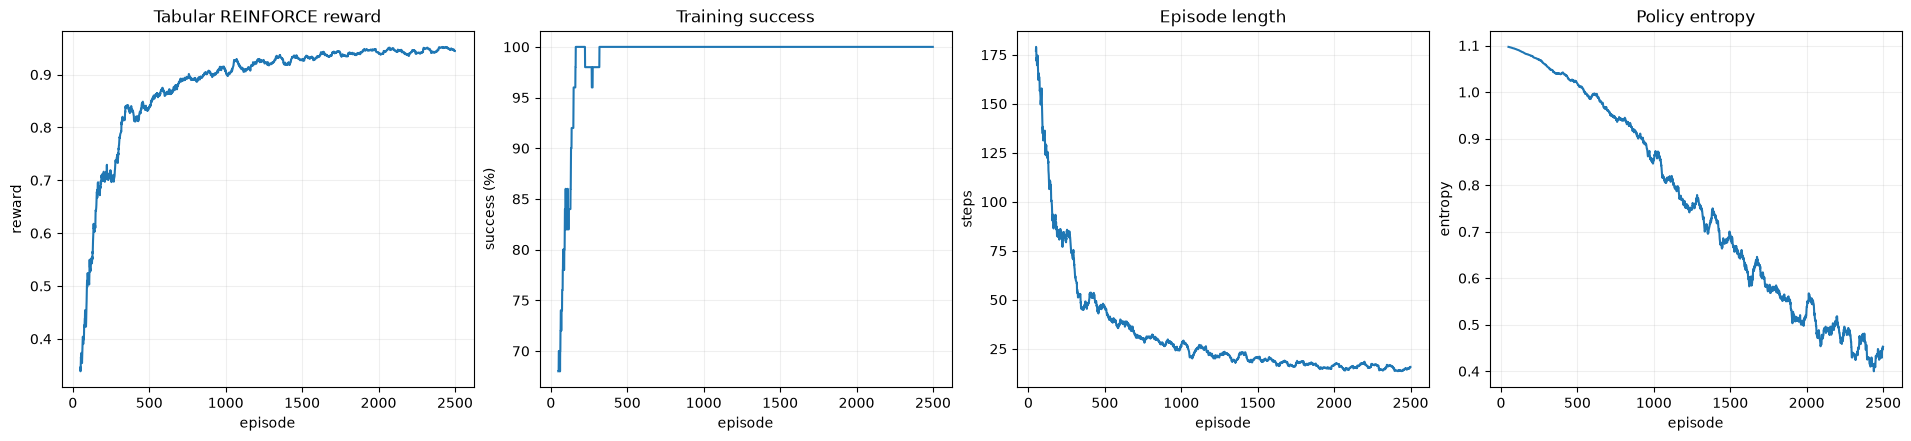

In [6]:
tabular_result = train_tabular_reinforce()

print(
    f"Last-100 reward: {tabular_result.episode_returns[-100:].mean():.3f} | "
    f"success: {100 * tabular_result.successes[-100:].mean():.1f}% | "
    f"steps: {tabular_result.episode_lengths[-100:].mean():.1f}"
)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.3), constrained_layout=True)
metrics = [
    (tabular_result.episode_returns, "reward", "Tabular REINFORCE reward"),
    (
        100 * tabular_result.successes.astype(float),
        "success (%)",
        "Training success",
    ),
    (tabular_result.episode_lengths, "steps", "Episode length"),
    (tabular_result.entropies, "entropy", "Policy entropy"),
]
for axis, (values, ylabel, title) in zip(axes, metrics):
    x_values, smooth_values = moving_average(values, window=50)
    axis.plot(x_values, smooth_values)
    axis.set_title(title)
    axis.set_xlabel("episode")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.2)
plt.show()

### 4.1 Evaluate and visualize the tabular policy

Training samples from the stochastic policy. For evaluation, greedy action selection exposes the most likely action at each state and removes sampling variance. We report both task success and path length, then save one native MiniGrid rollout as a GIF.

Tabular greedy evaluation: reward=0.961, steps=11.00, success=100.0%


Actions: forward → forward → forward → forward → forward → right → forward → forward → forward → forward → forward
Reward=0.961, steps=11, success=True


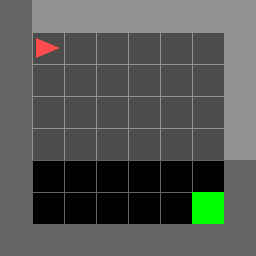

In [7]:
def tabular_policy_rollout(
    preferences,
    seed=0,
    greedy=True,
    capture_frames=False,
):
    env = make_env(render_mode="rgb_array" if capture_frames else None)
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    frames = [env.render().copy()] if capture_frames else []
    actions = []
    total_reward = 0.0
    terminated = truncated = False

    while not (terminated or truncated):
        state = get_agent_state(env)
        probabilities = stable_softmax(preferences[state])
        if greedy:
            candidates = np.flatnonzero(
                np.isclose(probabilities, probabilities.max())
            )
            local_action = int(rng.choice(candidates))
        else:
            local_action = int(rng.choice(len(NAV_ACTIONS), p=probabilities))
        _, reward, terminated, truncated, _ = env.step(
            int(NAV_ACTIONS[local_action])
        )
        actions.append(local_action)
        total_reward += float(reward)
        if capture_frames:
            frames.append(env.render().copy())

    steps = env.unwrapped.step_count
    env.close()
    return {
        "reward": total_reward,
        "steps": steps,
        "success": bool(terminated and total_reward > 0),
        "actions": actions,
        "frames": frames,
    }


tabular_evaluations = [
    tabular_policy_rollout(
        tabular_result.preferences, seed=1000 + episode, greedy=True
    )
    for episode in range(100)
]
print(
    "Tabular greedy evaluation: "
    f"reward={np.mean([item['reward'] for item in tabular_evaluations]):.3f}, "
    f"steps={np.mean([item['steps'] for item in tabular_evaluations]):.2f}, "
    f"success={100 * np.mean([item['success'] for item in tabular_evaluations]):.1f}%"
)

tabular_demo = tabular_policy_rollout(
    tabular_result.preferences,
    seed=2026,
    greedy=True,
    capture_frames=True,
)
tabular_gif = ARTIFACT_DIR / "minigrid_tabular_reinforce.gif"
imageio.mimsave(
    tabular_gif, tabular_demo["frames"], fps=5, loop=0
)
print(
    "Actions:",
    " → ".join(ACTION_NAMES[action] for action in tabular_demo["actions"]),
)
print(
    f"Reward={tabular_demo['reward']:.3f}, steps={tabular_demo['steps']}, "
    f"success={tabular_demo['success']}"
)
display(Image(filename=str(tabular_gif)))

### 4.2 Inspect the tabular probability maps

Each panel fixes the agent direction and shows the most probable relative action at every non-wall position. Background **hue** identifies the action, while saturation and the numeric label show its probability.

A tabular policy learns every $(x,y,d)$ entry independently. States visited on successful trajectories become confident, while rarely visited entries may remain close to the initial uniform distribution. The diagnostic below reports confidence, normalized entropy, and dominant-action counts so that the map is interpreted as a learned table rather than as spatial generalization.

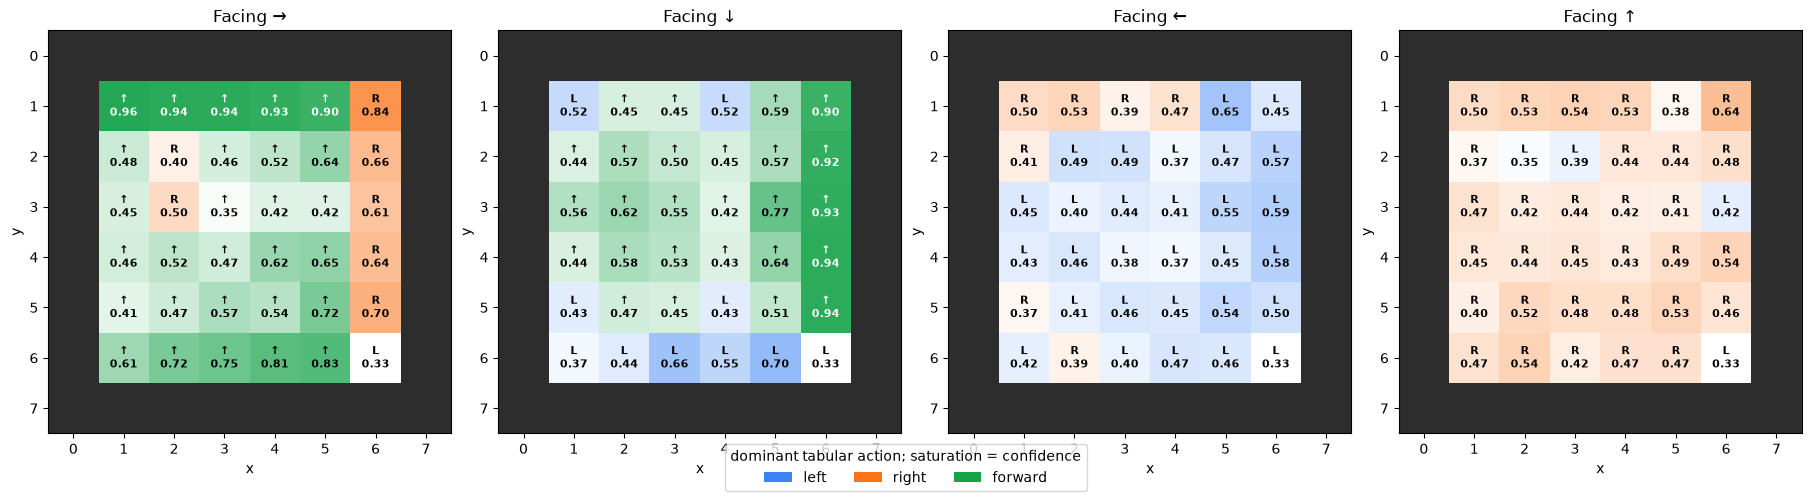

Tabular map | max-action probability min/median/max=0.3333/0.4740/0.9584 | mean normalized entropy=0.8746 | dominant actions={'left': 44, 'right': 46, 'forward': 54}


In [8]:
from matplotlib.patches import Patch


policy_map_env = make_env()
policy_map_env.reset(seed=SEED)
width = policy_map_env.unwrapped.width
height = policy_map_env.unwrapped.height
wall_mask = np.zeros((height, width), dtype=bool)
for x in range(width):
    for y in range(height):
        obj = policy_map_env.unwrapped.grid.get(x, y)
        wall_mask[y, x] = obj is not None and obj.type == "wall"


ACTION_RGB = np.array(
    [
        [0.23, 0.51, 0.96],  # left: blue
        [0.98, 0.45, 0.09],  # right: orange
        [0.09, 0.64, 0.29],  # forward: green
    ]
)
WALL_RGB = np.array([0.18, 0.18, 0.18])


def draw_tabular_probability_map(axis, direction, title):
    rgb_map = np.full((height, width, 3), WALL_RGB, dtype=float)
    labels = {}
    records = []
    for x in range(width):
        for y in range(height):
            if wall_mask[y, x]:
                continue
            probabilities = stable_softmax(
                tabular_result.preferences[(x, y, direction)]
            )
            best_action = int(np.argmax(probabilities))
            confidence = float(probabilities[best_action])
            normalized_entropy = float(
                -np.sum(probabilities * np.log(probabilities + 1e-12))
                / np.log(len(probabilities))
            )
            saturation = np.clip(
                (confidence - 1 / len(probabilities))
                / (1 - 1 / len(probabilities)),
                0.0,
                1.0,
            )
            rgb_map[y, x] = (
                (1 - saturation) * np.ones(3)
                + saturation * ACTION_RGB[best_action]
            )
            labels[(x, y)] = (
                ACTION_SYMBOLS[best_action],
                confidence,
                rgb_map[y, x],
            )
            records.append((confidence, normalized_entropy, best_action))

    axis.imshow(rgb_map, origin="upper")
    for (x, y), (symbol, confidence, color) in labels.items():
        luminance = float(
            0.2126 * color[0] + 0.7152 * color[1] + 0.0722 * color[2]
        )
        text_color = "black" if luminance > 0.58 else "white"
        axis.text(
            x,
            y,
            f"{symbol}\n{confidence:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
            fontweight="bold",
        )
    axis.set_title(title)
    axis.set_xticks(range(width))
    axis.set_yticks(range(height))
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    return records


fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), constrained_layout=True)
tabular_map_records = []
for direction in range(4):
    tabular_map_records.extend(
        draw_tabular_probability_map(
            axes[direction],
            direction,
            f"Facing {DIRECTION_SYMBOLS[direction]}",
        )
    )
legend_handles = [
    Patch(facecolor=ACTION_RGB[index], label=ACTION_NAMES[index])
    for index in range(len(ACTION_NAMES))
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(ACTION_NAMES),
    title="dominant tabular action; saturation = confidence",
    bbox_to_anchor=(0.5, -0.04),
)
plt.show()

confidence = np.array([record[0] for record in tabular_map_records])
normalized_entropy = np.array(
    [record[1] for record in tabular_map_records]
)
dominant_actions = np.array(
    [record[2] for record in tabular_map_records]
)
dominant_counts = {
    ACTION_NAMES[action]: int(np.sum(dominant_actions == action))
    for action in range(len(ACTION_NAMES))
}
print(
    "Tabular map | max-action probability "
    f"min/median/max={confidence.min():.4f}/"
    f"{np.median(confidence):.4f}/{confidence.max():.4f} | "
    f"mean normalized entropy={normalized_entropy.mean():.4f} | "
    f"dominant actions={dominant_counts}"
)
policy_map_env.close()

## 5. Neural REINFORCE on the AMD GPU

CartPole and PixelCopter return compact continuous feature vectors. Enumerating every possible vector in a table is not practical, so a policy network shares parameters across observations:

$$
\pi_\theta(a\mid s)=\operatorname{softmax}(f_\theta(s))_a.
$$

The environment still produces one transition at a time on the CPU. During each rollout, the policy forward pass and action distribution stay on the AMD GPU; only the sampled scalar action crosses back to the environment. After the episode, all stored features and actions are stacked and the differentiable REINFORCE update is recomputed as one GPU batch.

`require_amd_gpu()` is called both when training and when evaluating a model. This makes device placement an enforced invariant rather than a best-effort preference.

In [9]:
DEVICE = require_amd_gpu()
print(
    "Neural sections locked to:",
    torch.cuda.get_device_name(DEVICE),
    f"via ROCm/HIP {torch.version.hip}",
)


@dataclass
class VectorReinforceResult:
    model: nn.Module
    episode_returns: np.ndarray
    episode_lengths: np.ndarray
    losses: np.ndarray
    entropies: np.ndarray
    elapsed_seconds: float
    peak_memory_mib: float


class VectorPolicyNetwork(nn.Module):
    def __init__(self, input_size, action_size, hidden_sizes=(64,)):
        super().__init__()
        layers = []
        previous_size = input_size
        for hidden_size in hidden_sizes:
            layers.extend(
                [nn.Linear(previous_size, hidden_size), nn.ReLU()]
            )
            previous_size = hidden_size
        layers.append(nn.Linear(previous_size, action_size))
        self.network = nn.Sequential(*layers)

    def forward(self, features):
        return self.network(features)


def standardized_returns(rewards, gamma, device):
    discounted_return = 0.0
    returns_to_go = []
    for reward in reversed(rewards):
        discounted_return = float(reward) + gamma * discounted_return
        returns_to_go.append(discounted_return)
    returns = torch.tensor(
        list(reversed(returns_to_go)),
        dtype=torch.float32,
        device=device,
    )
    return (returns - returns.mean()) / (
        returns.std(unbiased=False) + torch.finfo(torch.float32).eps
    )


def train_vector_reinforce(
    env_factory,
    preprocess_observation,
    episodes,
    hidden_sizes,
    learning_rate,
    gamma,
    max_steps,
    seed,
    print_every,
    device=DEVICE,
):
    device = require_amd_gpu(device)
    seed_torch(seed)
    np.random.seed(seed)
    torch.cuda.reset_peak_memory_stats(device)

    probe_env = env_factory()
    initial_observation, _ = probe_env.reset(seed=seed)
    input_size = len(preprocess_observation(initial_observation))
    action_size = probe_env.action_space.n
    probe_env.close()

    env = env_factory()
    model = VectorPolicyNetwork(
        input_size, action_size, hidden_sizes
    ).to(device)
    if model_device(model).type != "cuda":
        raise RuntimeError("Policy network was not placed on the AMD GPU.")
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    episode_returns = np.zeros(episodes, dtype=float)
    episode_lengths = np.zeros(episodes, dtype=int)
    losses = np.zeros(episodes, dtype=float)
    entropies = np.zeros(episodes, dtype=float)

    torch.cuda.synchronize(device)
    started = time.perf_counter()

    for episode in range(episodes):
        observation, _ = env.reset(seed=seed + episode)
        feature_rows = []
        sampled_actions = []
        rewards = []

        for step in range(1, max_steps + 1):
            features = np.asarray(
                preprocess_observation(observation), dtype=np.float32
            )
            model.eval()
            with torch.inference_mode():
                feature_tensor = torch.from_numpy(features).to(device)
                logits = model(feature_tensor)
                action = Categorical(logits=logits).sample()
            action_index = int(action.item())
            observation, reward, terminated, truncated, _ = env.step(
                action_index
            )
            feature_rows.append(features)
            sampled_actions.append(action_index)
            rewards.append(float(reward))
            if terminated or truncated:
                break

        returns = standardized_returns(rewards, gamma, device)
        trajectory_features = torch.from_numpy(
            np.stack(feature_rows)
        ).to(device)
        trajectory_actions = torch.tensor(
            sampled_actions, dtype=torch.long, device=device
        )
        model.train()
        distribution = Categorical(logits=model(trajectory_features))
        log_probabilities = distribution.log_prob(trajectory_actions)
        entropy_tensor = distribution.entropy()
        loss = -torch.sum(log_probabilities * returns)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        episode_returns[episode] = sum(rewards)
        episode_lengths[episode] = len(rewards)
        losses[episode] = float(loss.detach().cpu())
        entropies[episode] = float(
            entropy_tensor.mean().detach().cpu()
        )

        if (episode + 1) % print_every == 0:
            recent = slice(max(0, episode - 99), episode + 1)
            print(
                f"Episode {episode + 1:>5}/{episodes} | "
                f"mean score={episode_returns[recent].mean():.2f} | "
                f"mean length={episode_lengths[recent].mean():.1f}"
            )

    torch.cuda.synchronize(device)
    elapsed_seconds = time.perf_counter() - started
    peak_memory_mib = (
        torch.cuda.max_memory_allocated(device) / 2**20
    )
    env.close()
    return VectorReinforceResult(
        model,
        episode_returns,
        episode_lengths,
        losses,
        entropies,
        elapsed_seconds,
        peak_memory_mib,
    )


def vector_policy_rollout(
    env_factory,
    preprocess_observation,
    model,
    seed,
    max_steps,
    greedy=False,
    capture_frames=False,
):
    device = require_amd_gpu(model_device(model))
    env = env_factory(render_mode="rgb_array" if capture_frames else None)
    observation, _ = env.reset(seed=seed)
    seed_torch(seed)
    frames = [env.render().copy()] if capture_frames else []
    actions = []
    total_reward = 0.0
    terminated = truncated = False
    model.eval()

    with torch.inference_mode():
        for _ in range(max_steps):
            features = torch.as_tensor(
                preprocess_observation(observation),
                dtype=torch.float32,
                device=device,
            )
            logits = model(features)
            action = (
                int(torch.argmax(logits).item())
                if greedy
                else int(Categorical(logits=logits).sample().item())
            )
            observation, reward, terminated, truncated, _ = env.step(action)
            actions.append(action)
            total_reward += float(reward)
            if capture_frames:
                frames.append(env.render().copy())
            if terminated or truncated:
                break

    env.close()
    return {
        "reward": total_reward,
        "steps": len(actions),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "actions": actions,
        "frames": frames,
    }


def evaluate_vector_policy(
    env_factory,
    preprocess_observation,
    model,
    episodes,
    seed,
    max_steps,
    greedy,
):
    rollouts = [
        vector_policy_rollout(
            env_factory,
            preprocess_observation,
            model,
            seed + episode,
            max_steps,
            greedy=greedy,
        )
        for episode in range(episodes)
    ]
    return {
        "rewards": np.asarray([item["reward"] for item in rollouts]),
        "lengths": np.asarray([item["steps"] for item in rollouts]),
    }

Neural sections locked to: Radeon 8060S Graphics via ROCm/HIP 7.13.99004-3309c6114a


### 5.1 CPU versus AMD GPU batch-update benchmark

The benchmark below isolates the tensor work that an accelerator can speed up. It uses the PixelCopter policy architecture, a synthetic batch of 16,384 transitions, five warm-up updates, and 30 measured forward/backward optimizer updates. Synchronizing before and after timing prevents asynchronous GPU launches from producing a misleading result.

This is not a full environment benchmark. CartPole and PixelCopter still call `env.step()` sequentially on the CPU, and action selection uses a batch of one. Therefore end-to-end training speedup will be smaller than the batched update speedup shown here.

In [10]:
def benchmark_policy_updates(
    device,
    batch_size=16_384,
    warmup_updates=5,
    measured_updates=30,
):
    device = torch.device(device)
    seed_torch(SEED)
    model = VectorPolicyNetwork(
        input_size=7,
        action_size=2,
        hidden_sizes=(64, 128),
    ).to(device)
    features = torch.randn(batch_size, 7, device=device)
    actions = torch.randint(0, 2, (batch_size,), device=device)
    advantages = torch.randn(batch_size, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    def update_once():
        distribution = Categorical(logits=model(features))
        loss = -(
            distribution.log_prob(actions) * advantages
        ).mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    for _ in range(warmup_updates):
        update_once()
    if device.type == "cuda":
        torch.cuda.synchronize(device)

    started = time.perf_counter()
    for _ in range(measured_updates):
        update_once()
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    return (
        1000
        * (time.perf_counter() - started)
        / measured_updates
    )


cpu_update_ms = benchmark_policy_updates(torch.device("cpu"))
gpu_update_ms = benchmark_policy_updates(DEVICE)
gpu_speedup = cpu_update_ms / gpu_update_ms

print(f"CPU batch update:     {cpu_update_ms:.2f} ms")
print(f"AMD GPU batch update: {gpu_update_ms:.2f} ms")
print(f"AMD GPU speedup:      {gpu_speedup:.2f}×")

CPU batch update:     60.77 ms
AMD GPU batch update: 3.02 ms
AMD GPU speedup:      20.09×


## 6. CartPole-v1

Next we validate the reusable REINFORCE implementation on CartPole before moving to the harder PixelCopter environment. A small continuous-state control task makes integration bugs easier to distinguish from genuine learning difficulty.

CartPole observations contain cart position and velocity plus pole angle and angular velocity. The two actions push left or right. A reward of one is received at every balanced step, so the maximum 500-step return is an unambiguous solved-task reference.

In [11]:
CARTPOLE_ENV_NAME = "CartPole-v1"
CARTPOLE_FEATURE_NAMES = (
    "cart position",
    "cart velocity",
    "pole angle",
    "pole angular velocity",
)


def cartpole_factory(render_mode=None):
    return gym.make(CARTPOLE_ENV_NAME, render_mode=render_mode)


def cartpole_preprocess(observation):
    return np.asarray(observation, dtype=np.float32)


cartpole_preview = cartpole_factory()
cartpole_observation, _ = cartpole_preview.reset(seed=SEED)
print("Environment:", CARTPOLE_ENV_NAME)
print("Observation space:", cartpole_preview.observation_space)
print("Action space:", cartpole_preview.action_space)
print(
    "Initial observation:",
    dict(zip(CARTPOLE_FEATURE_NAMES, np.round(cartpole_observation, 4))),
)
cartpole_preview.close()

Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: {'cart position': np.float32(0.0345), 'cart velocity': np.float32(-0.0339), 'pole angle': np.float32(0.0058), 'pole angular velocity': np.float32(-0.0132)}


Episode   250/1000 | mean score=384.10 | mean length=384.1


Episode   500/1000 | mean score=462.59 | mean length=462.6


Episode   750/1000 | mean score=454.01 | mean length=454.0


Episode  1000/1000 | mean score=490.69 | mean length=490.7
CartPole training: 76.4 s on cuda:0
Peak PyTorch GPU memory: 108.1 MiB


CartPole stochastic: reward=460.82 ± 64.96, mean steps=460.82
CartPole     greedy: reward=456.26 ± 43.81, mean steps=456.26


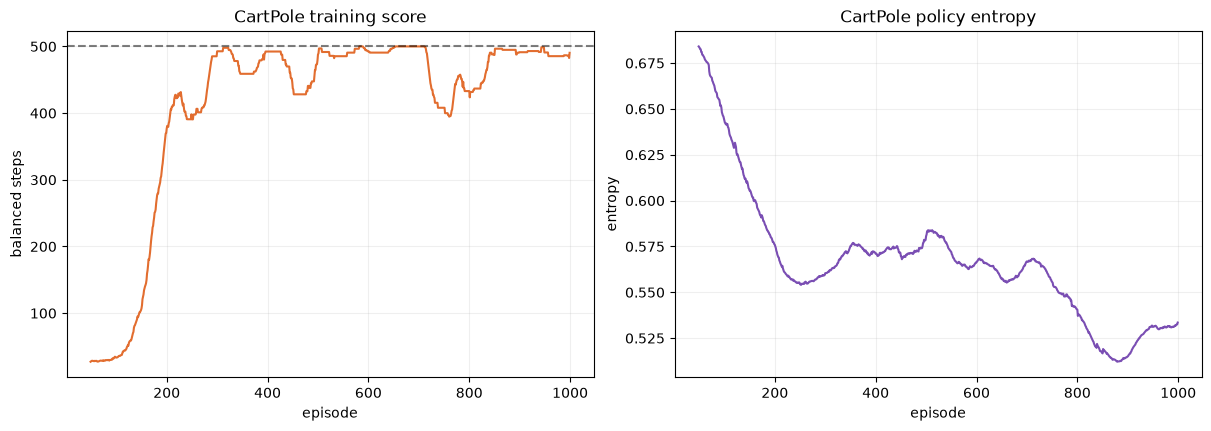

CartPole demo: reward=404.0, steps=404, truncated=False


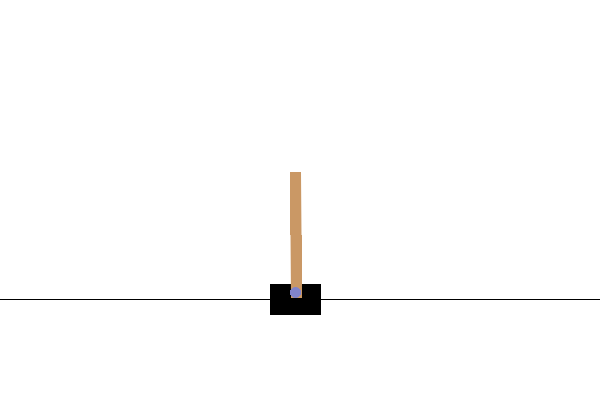

In [12]:
cartpole_result = train_vector_reinforce(
    env_factory=cartpole_factory,
    preprocess_observation=cartpole_preprocess,
    episodes=1000,
    hidden_sizes=(16,),
    learning_rate=1e-2,
    gamma=1.0,
    max_steps=500,
    seed=SEED,
    print_every=250,
)

print(
    f"CartPole training: {cartpole_result.elapsed_seconds:.1f} s on "
    f"{model_device(cartpole_result.model)}"
)
if DEVICE.type == "cuda":
    print(f"Peak PyTorch GPU memory: {cartpole_result.peak_memory_mib:.1f} MiB")

cartpole_stochastic_evaluation = evaluate_vector_policy(
    cartpole_factory,
    cartpole_preprocess,
    cartpole_result.model,
    episodes=50,
    seed=5000,
    max_steps=500,
    greedy=False,
)
cartpole_greedy_evaluation = evaluate_vector_policy(
    cartpole_factory,
    cartpole_preprocess,
    cartpole_result.model,
    episodes=50,
    seed=6000,
    max_steps=500,
    greedy=True,
)

for label, evaluation in [
    ("stochastic", cartpole_stochastic_evaluation),
    ("greedy", cartpole_greedy_evaluation),
]:
    print(
        f"CartPole {label:>10}: "
        f"reward={evaluation['rewards'].mean():.2f} ± {evaluation['rewards'].std():.2f}, "
        f"mean steps={evaluation['lengths'].mean():.2f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
cartpole_x, cartpole_score_mean = moving_average(
    cartpole_result.episode_returns, window=50
)
_, cartpole_entropy_mean = moving_average(
    cartpole_result.entropies, window=50
)
axes[0].plot(cartpole_x, cartpole_score_mean, color="#e26d2f")
axes[0].axhline(500, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("CartPole training score")
axes[0].set_ylabel("balanced steps")
axes[1].plot(cartpole_x, cartpole_entropy_mean, color="#7a4eb3")
axes[1].set_title("CartPole policy entropy")
axes[1].set_ylabel("entropy")
for axis in axes:
    axis.set_xlabel("episode")
    axis.grid(alpha=0.2)
plt.show()

cartpole_demo = vector_policy_rollout(
    cartpole_factory,
    cartpole_preprocess,
    cartpole_result.model,
    seed=2026,
    max_steps=500,
    greedy=True,
    capture_frames=True,
)
cartpole_gif = ARTIFACT_DIR / "cartpole_reinforce.gif"
imageio.mimsave(
    cartpole_gif, cartpole_demo["frames"][::2], fps=30, loop=0
)
print(
    f"CartPole demo: reward={cartpole_demo['reward']:.1f}, "
    f"steps={cartpole_demo['steps']}, truncated={cartpole_demo['truncated']}"
)
display(Image(filename=str(cartpole_gif)))

## 7. PixelCopter

PixelCopter comes from the [PyGame Learning Environment](https://pygame-learning-environment.readthedocs.io/en/latest/user/games/pixelcopter.html). The Hugging Face hands-on accesses it through the legacy Gym environment Pixelcopter-PLE-v0. That integration still uses the old reset/step API, so this notebook provides a small Gymnasium adapter with reproducible reset seeds and separate terminated/truncated flags.

Despite its name, the Hugging Face experiment does **not** train from RGB pixels. Its policy receives seven state features: player height and velocity, distance to ceiling and floor, horizontal distance to the next gate, and the gate's upper and lower boundaries. RGB frames are used only for visualization. The reset frame is completely black, so the rollout GIF intentionally begins after the first environment action.

The two actions are accelerate upward and do nothing. Passing a gate gives $+1$ and crashing gives $-1$. This event-based reward is less dense than CartPole and the environment is more variable, so the policy uses two hidden layers and a substantially longer training run. Hugging Face uses 50,000 episodes for its full benchmark; this tutorial uses **15,000 episodes**, three times the earlier classroom budget, to improve performance while keeping the run practical.

In [13]:
PIXELCOPTER_STATE_KEYS = (
    "player_y",
    "player_vel",
    "player_dist_to_ceil",
    "player_dist_to_floor",
    "next_gate_dist_to_player",
    "next_gate_block_top",
    "next_gate_block_bottom",
)
PIXELCOPTER_ACTION_NAMES = ("accelerate up", "do nothing")
PIXELCOPTER_SCALE = np.array([48, 10, 48, 48, 48, 48, 48], dtype=np.float32)


class PixelcopterGymnasiumEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array"], "render_fps": 30}

    def __init__(self, render_mode=None, max_episode_steps=1000, seed=0):
        self.render_mode = render_mode
        self.max_episode_steps = max_episode_steps
        self.game = Pixelcopter(width=48, height=48)
        self.ple = PLE(
            self.game,
            fps=30,
            display_screen=False,
            force_fps=True,
            rng=seed,
        )
        self.ple_actions = self.ple.getActionSet()
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(7,),
            dtype=np.float32,
        )
        self.steps = 0

    def _observation(self):
        state = self.ple.getGameState()
        return np.asarray(
            [state[key] for key in PIXELCOPTER_STATE_KEYS],
            dtype=np.float32,
        )

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.ple.rng.seed(seed)
            self.game.setRNG(self.ple.rng)
            self.action_space.seed(seed)
        self.ple.reset_game()
        self.steps = 0
        return self._observation(), {}

    def step(self, action):
        reward = float(self.ple.act(self.ple_actions[int(action)]))
        self.steps += 1
        terminated = bool(self.ple.game_over())
        truncated = bool(
            self.steps >= self.max_episode_steps and not terminated
        )
        return self._observation(), reward, terminated, truncated, {}

    def render(self):
        return self.ple.getScreenRGB().copy()

    def close(self):
        pass


def pixelcopter_factory(render_mode=None):
    return PixelcopterGymnasiumEnv(
        render_mode=render_mode, max_episode_steps=1000
    )


def pixelcopter_preprocess(observation):
    return np.asarray(observation, dtype=np.float32) / PIXELCOPTER_SCALE


pixelcopter_preview = pixelcopter_factory()
pixelcopter_observation, _ = pixelcopter_preview.reset(seed=SEED)
print("Observation space:", pixelcopter_preview.observation_space)
print("Action mapping:", dict(enumerate(PIXELCOPTER_ACTION_NAMES)))
print(
    "Initial observation:",
    dict(zip(PIXELCOPTER_STATE_KEYS, pixelcopter_observation)),
)
pixelcopter_preview.close()

Observation space: Box(-inf, inf, (7,), float32)
Action mapping: {0: 'accelerate up', 1: 'do nothing'}
Initial observation: {'player_y': np.float32(24.0), 'player_vel': np.float32(0.0), 'player_dist_to_ceil': np.float32(7.0), 'player_dist_to_floor': np.float32(17.0), 'next_gate_dist_to_player': np.float32(47.0), 'next_gate_block_top': np.float32(29.0), 'next_gate_block_bottom': np.float32(38.0)}


Episode  3000/15000 | mean score=1.49 | mean length=45.6


Episode  6000/15000 | mean score=8.37 | mean length=86.4


Episode  9000/15000 | mean score=11.64 | mean length=105.2


Episode 12000/15000 | mean score=13.52 | mean length=116.4


Episode 15000/15000 | mean score=18.70 | mean length=145.6
PixelCopter training: 385.2 s on cuda:0
Peak PyTorch GPU memory: 109.8 MiB
Last-100 PixelCopter score: 18.70 | mean steps: 145.6


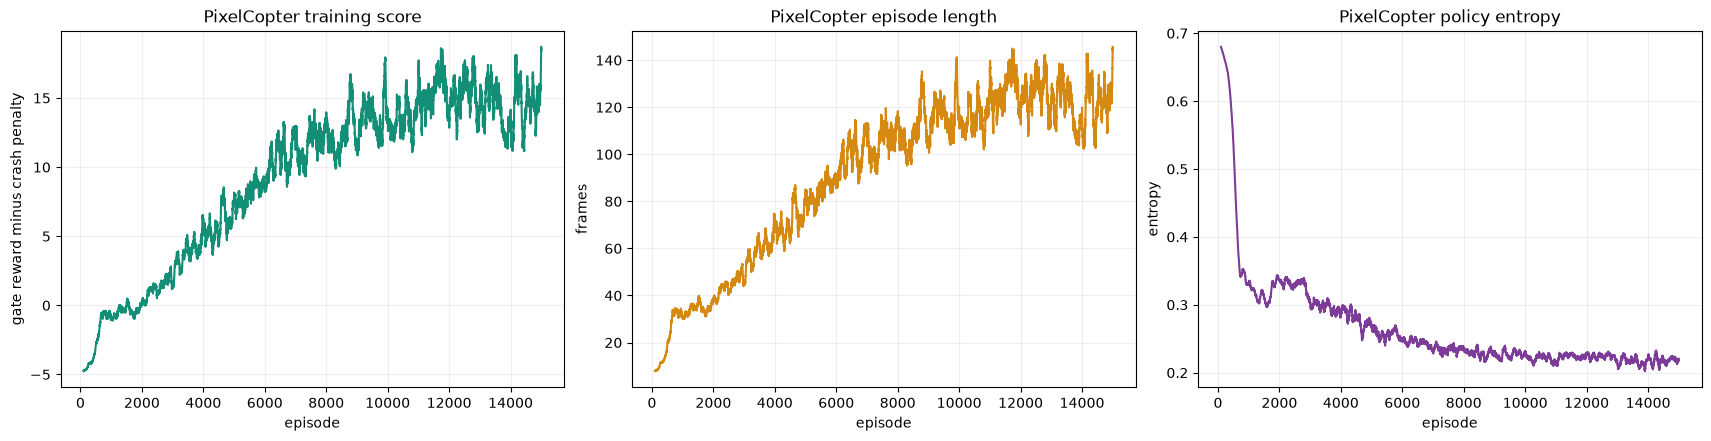

In [14]:
pixelcopter_result = train_vector_reinforce(
    env_factory=pixelcopter_factory,
    preprocess_observation=pixelcopter_preprocess,
    episodes=15_000,
    hidden_sizes=(64, 128),
    learning_rate=1e-4,
    gamma=0.99,
    max_steps=1000,
    seed=50,
    print_every=3000,
)

print(
    f"PixelCopter training: {pixelcopter_result.elapsed_seconds:.1f} s on "
    f"{model_device(pixelcopter_result.model)}"
)
print(
    f"Peak PyTorch GPU memory: "
    f"{pixelcopter_result.peak_memory_mib:.1f} MiB"
)

print(
    f"Last-100 PixelCopter score: "
    f"{pixelcopter_result.episode_returns[-100:].mean():.2f} | "
    f"mean steps: "
    f"{pixelcopter_result.episode_lengths[-100:].mean():.1f}"
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), constrained_layout=True)
pixel_x, pixel_score_mean = moving_average(
    pixelcopter_result.episode_returns, window=100
)
_, pixel_length_mean = moving_average(
    pixelcopter_result.episode_lengths, window=100
)
_, pixel_entropy_mean = moving_average(
    pixelcopter_result.entropies, window=100
)
axes[0].plot(pixel_x, pixel_score_mean, color="#148f77")
axes[0].set_title("PixelCopter training score")
axes[0].set_ylabel("gate reward minus crash penalty")
axes[1].plot(pixel_x, pixel_length_mean, color="#d68910")
axes[1].set_title("PixelCopter episode length")
axes[1].set_ylabel("frames")
axes[2].plot(pixel_x, pixel_entropy_mean, color="#7d3c98")
axes[2].set_title("PixelCopter policy entropy")
axes[2].set_ylabel("entropy")
for axis in axes:
    axis.set_xlabel("episode")
    axis.grid(alpha=0.2)
plt.show()

PixelCopter stochastic: reward=16.15 ± 14.15, mean steps=131.3
PixelCopter     greedy: reward=14.05 ± 13.01, mean steps=119.1


Representative stochastic rollout: seed=10024, reward=14.0, steps=121


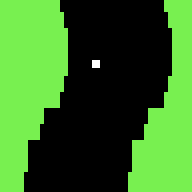

In [15]:
pixelcopter_stochastic_evaluation = evaluate_vector_policy(
    pixelcopter_factory,
    pixelcopter_preprocess,
    pixelcopter_result.model,
    episodes=100,
    seed=10_000,
    max_steps=1000,
    greedy=False,
)
pixelcopter_greedy_evaluation = evaluate_vector_policy(
    pixelcopter_factory,
    pixelcopter_preprocess,
    pixelcopter_result.model,
    episodes=100,
    seed=20_000,
    max_steps=1000,
    greedy=True,
)

for label, evaluation in [
    ("stochastic", pixelcopter_stochastic_evaluation),
    ("greedy", pixelcopter_greedy_evaluation),
]:
    print(
        f"PixelCopter {label:>10}: "
        f"reward={evaluation['rewards'].mean():.2f} "
        f"± {evaluation['rewards'].std():.2f}, "
        f"mean steps={evaluation['lengths'].mean():.1f}"
    )

ordered_indices = np.argsort(
    pixelcopter_stochastic_evaluation["rewards"]
)
representative_index = int(
    ordered_indices[len(ordered_indices) // 2]
)
representative_seed = 10_000 + representative_index
pixelcopter_demo = vector_policy_rollout(
    pixelcopter_factory,
    pixelcopter_preprocess,
    pixelcopter_result.model,
    seed=representative_seed,
    max_steps=1000,
    greedy=False,
    capture_frames=True,
)
pixelcopter_gif = ARTIFACT_DIR / "pixelcopter_reinforce.gif"
pixelcopter_frames = [
    np.repeat(np.repeat(frame, 4, axis=0), 4, axis=1)
    for frame in pixelcopter_demo["frames"][1:]
]
imageio.mimsave(
    pixelcopter_gif, pixelcopter_frames, fps=30, loop=0
)
print(
    f"Representative stochastic rollout: seed={representative_seed}, "
    f"reward={pixelcopter_demo['reward']:.1f}, "
    f"steps={pixelcopter_demo['steps']}"
)
display(Image(filename=str(pixelcopter_gif)))

## 8. What the Three Environments Reveal

| Environment | Policy representation | Actions | Reward character | Main lesson |
|---|---|---:|---|---|
| MiniGrid Empty | Tabular preferences indexed by $(x,y,d)$ | 3 | sparse terminal reward | a small discrete task keeps the policy-gradient update directly inspectable |
| CartPole-v1 | Neural policy over 4 continuous features | 2 | dense $+1$ per step | a small environment is ideal for debugging GPU-backed policy learning |
| PixelCopter | Neural policy over 7 normalized features | 2 | gate events and crash penalty | longer training and stochastic evaluation matter |

The representation changes from an explicit table to shared network weights, but the estimator does not: sample actions, compute return-to-go, and increase the log probability of actions in proportion to their standardized returns.

The Hugging Face certification score is mean reward minus reward standard deviation. We print that conservative statistic below. The 15,000-episode PixelCopter run is still shorter than the course's 50,000-episode benchmark, so its result should be interpreted as a classroom experiment rather than as a certification submission.

     environment |  policy | act | episodes |       mode |    reward mean ± std
------------------------------------------------------------------------------------------
  MiniGrid Empty | tabular |   3 |     2500 |     greedy |     0.96 ± 0.00    
     CartPole-v1 |  neural |   2 |     1000 | stochastic |   460.82 ± 64.96   
     PixelCopter |  neural |   2 |    15000 | stochastic |    16.15 ± 14.15   

CartPole mean - std: 395.86
PixelCopter mean - std: 2.00


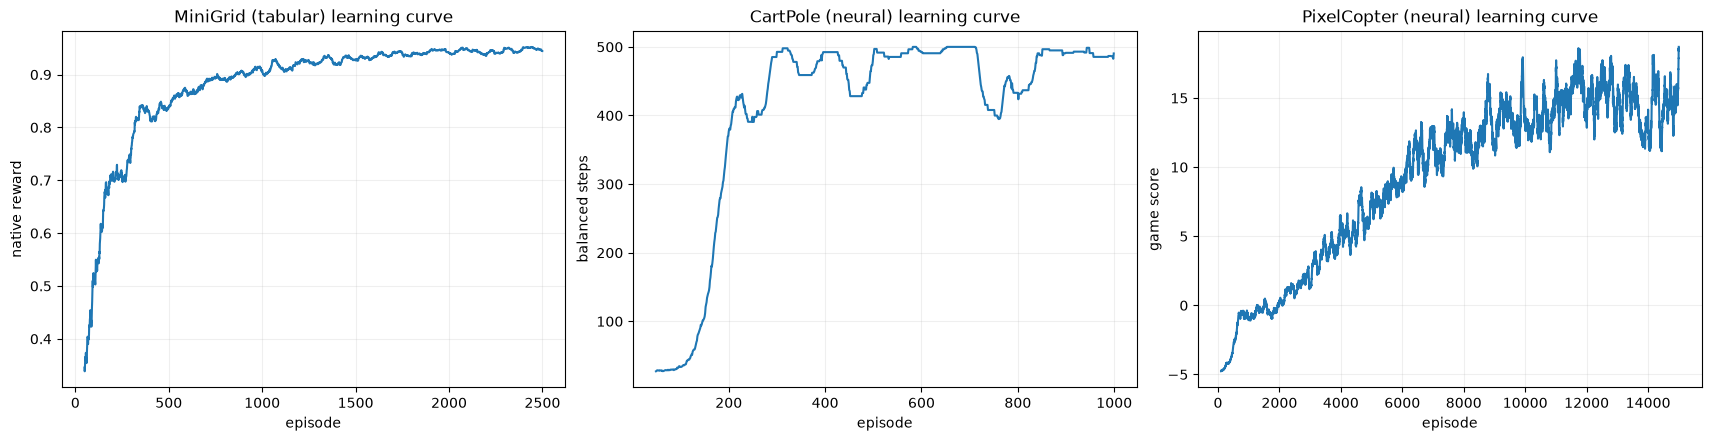

In [16]:
minigrid_rewards = np.asarray(
    [item["reward"] for item in tabular_evaluations],
    dtype=float,
)

summary_rows = [
    (
        "MiniGrid Empty",
        "tabular",
        3,
        2500,
        "greedy",
        minigrid_rewards.mean(),
        minigrid_rewards.std(),
    ),
    (
        "CartPole-v1",
        "neural",
        2,
        1000,
        "stochastic",
        cartpole_stochastic_evaluation["rewards"].mean(),
        cartpole_stochastic_evaluation["rewards"].std(),
    ),
    (
        "PixelCopter",
        "neural",
        2,
        15_000,
        "stochastic",
        pixelcopter_stochastic_evaluation["rewards"].mean(),
        pixelcopter_stochastic_evaluation["rewards"].std(),
    ),
]

print(
    f"{'environment':>16} | {'policy':>7} | {'act':>3} | "
    f"{'episodes':>8} | {'mode':>10} | "
    f"{'reward mean ± std':>20}"
)
print("-" * 90)
for (
    environment,
    policy_type,
    action_size,
    episodes,
    mode,
    mean,
    std,
) in summary_rows:
    print(
        f"{environment:>16} | {policy_type:>7} | "
        f"{action_size:>3} | {episodes:>8} | "
        f"{mode:>10} | {mean:>8.2f} ± {std:<8.2f}"
    )

cartpole_conservative_score = (
    cartpole_stochastic_evaluation["rewards"].mean()
    - cartpole_stochastic_evaluation["rewards"].std()
)
pixelcopter_conservative_score = (
    pixelcopter_stochastic_evaluation["rewards"].mean()
    - pixelcopter_stochastic_evaluation["rewards"].std()
)
print(f"\nCartPole mean - std: {cartpole_conservative_score:.2f}")
print(f"PixelCopter mean - std: {pixelcopter_conservative_score:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), constrained_layout=True)
training_series = [
    (
        tabular_result.episode_returns,
        50,
        "MiniGrid (tabular)",
        "native reward",
    ),
    (
        cartpole_result.episode_returns,
        50,
        "CartPole (neural)",
        "balanced steps",
    ),
    (
        pixelcopter_result.episode_returns,
        100,
        "PixelCopter (neural)",
        "game score",
    ),
]
for axis, (values, window, title, ylabel) in zip(
    axes, training_series
):
    x_values, smooth_values = moving_average(values, window=window)
    axis.plot(x_values, smooth_values)
    axis.set_title(f"{title} learning curve")
    axis.set_xlabel("episode")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.2)
plt.show()

## 9. From Tabular Preferences to Neural Policies

| Component | Tabular softmax policy | PyTorch policy network |
|---|---|---|
| State representation | Direct $(x,y,d)$ index | Environment-specific feature vector |
| Parameters | One preference vector per state | Shared neural-network weights |
| Action distribution | NumPy softmax | PyTorch Categorical distribution |
| Gradient | Written analytically | Computed by autograd |
| Generalization | None between table entries | Possible through shared features |
| Optimization | Direct gradient-ascent update | Adam minimizes a negative objective |

PyTorch does not change the policy-gradient theorem. It changes how $\pi_\theta$ is represented and how its derivatives are computed.

For image observations, the same interface can use a convolutional encoder. For continuous actions, a policy can output the mean and scale of a Gaussian distribution. Adding a learned value baseline produces an **actor–critic** method: the policy is the actor and the value estimator is the critic.

## Conclusions

In this lab, you completed a policy-gradient workflow with a deliberate representation boundary:

- Derived and implemented Monte Carlo REINFORCE
- Trained MiniGrid with an explicit NumPy preference table and state baseline
- Inspected MiniGrid action probabilities without introducing a policy network
- Built PyTorch policy networks only for CartPole and PixelCopter
- Enforced AMD ROCm placement for neural training and evaluation
- Compared CPU and AMD GPU throughput on batched policy updates
- Preserved on-policy data while recomputing each trajectory as a GPU batch
- Extended PixelCopter training from 5,000 to 15,000 episodes
- Compared stochastic sampling with greedy action selection
- Produced looping animated rollouts for all three environments

Policy gradients optimize behavior directly, but their Monte Carlo estimates are noisy. The next natural step is actor–critic learning, where a learned value function reduces variance while retaining a parameterized policy.

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.  
SPDX-License-Identifier: MIT